## Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2 — Create the Dataset

We have two types of news:
- **Label 0** = Real News
- **Label 1** = Fake News

In [4]:
# Real news examples
real_news = [
    "Government announces new budget plan for education sector",
    "Scientists find new treatment for diabetes in clinical trial",
    "Stock market rises after positive jobs report",
    "NASA launches new satellite to study climate change",
    "Prime Minister holds press conference on economic policy",
    "New study shows benefits of Mediterranean diet for heart health",
    "Electric vehicle sales hit record high this quarter",
    "Supreme court passes new ruling on environmental law",
    "UN holds summit on global food security crisis",
    "Hospital reports decline in covid cases this month",
    "Central bank keeps interest rates unchanged this quarter",
    "Scientists publish research on effects of climate change",
    "New law passed to protect consumer data privacy",
    "World health organization updates vaccine guidelines",
    "Tech company announces layoffs amid market slowdown",
]

# Fake news examples
fake_news = [
    "SHOCKING secret the government is hiding from everyone",
    "You won't believe what they found in the vaccine",
    "Miracle cure doctors don't want you to know about",
    "BREAKING celebrity caught in massive secret society scandal",
    "Deep state exposed share before they delete this",
    "Moon landing was faked whistleblower finally confirms",
    "Bill gates putting microchips in vaccines to control people",
    "Election was rigged insider reveals the truth now",
    "5G towers spreading virus wake up people",
    "Scientists STUNNED flat earth proof found in antarctica",
    "Secret cure for cancer hidden by big pharma exposed",
    "Chemtrails contain mind control chemicals truth revealed",
    "Hollywood elite running secret underground operations exposed",
    "EXCLUSIVE whistleblower leaks massive government cover up",
    "New world order plans leaked by anonymous insider",
]

# Combine into one dataframe
# Label 0 = Real, Label 1 = Fake
texts  = real_news + fake_news
labels = [0] * len(real_news) + [1] * len(fake_news)

df = pd.DataFrame({'text': texts, 'label': labels})

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset created!')
print('Total rows    :', len(df))
print('Real news (0) :', (df['label'] == 0).sum())
print('Fake news (1) :', (df['label'] == 1).sum())
print()
df.head(10)

Dataset created!
Total rows    : 30
Real news (0) : 15
Fake news (1) : 15



,text,label
0,Hollywood elite running secret underground ope...,1
1,SHOCKING secret the government is hiding from ...,1
2,5G towers spreading virus wake up people,1
3,Miracle cure doctors don't want you to know about,1
4,UN holds summit on global food security crisis,0
5,Hospital reports decline in covid cases this m...,0
6,EXCLUSIVE whistleblower leaks massive governme...,1
7,Scientists STUNNED flat earth proof found in a...,1
8,New law passed to protect consumer data privacy,0
9,Government announces new budget plan for educa...,0


## Step 3 — Clean the Text

We clean the text so the model can understand it better.


In [5]:
def clean_text(text):
    text = text.lower()                                                   # make lowercase
    text = re.sub(r'\d+', '', text)                                       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))      # remove punctuation
    text = text.strip()                                                   # remove extra spaces
    return text

# Apply cleaning to every row
df['clean_text'] = df['text'].apply(clean_text)

# Show before and after
print('BEFORE:', df['text'].iloc[0])
print('AFTER :', df['clean_text'].iloc[0])

BEFORE: Hollywood elite running secret underground operations exposed
AFTER : hollywood elite running secret underground operations exposed


## Step 4 — Convert Text to Numbers (TF-IDF)

Machine learning models **cannot read text**. They only understand numbers.

So we use **TF-IDF** to convert each word into a number.

- Words that are **important and rare** → get a HIGH number
- Common words like 'the', 'is', 'and' → get a LOW number or removed

In [6]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=500, stop_words='english')

X = tfidf.fit_transform(df['clean_text'])  # convert text to numbers
y = df['label']                            # 0 = real, 1 = fake

print('Text converted to numbers!')
print('Shape of X:', X.shape)
print('This means:', X.shape[0], 'articles, each with', X.shape[1], 'number features')

Text converted to numbers!
Shape of X: (30, 153)
This means: 30 articles, each with 153 number features


## Step 5 — Split Data into Train and Test

- **Training data** → model learns from this (80%)
- **Testing data** → we check how good the model is (20%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # same result every time
)

print('Train size :', X_train.shape[0])
print('Test size  :', X_test.shape[0])

Train size : 24
Test size  : 6


## Step 6 — Train the Model

We use **Logistic Regression** — a simple and popular ML algorithm.

It learns patterns like:
- If headline has words like 'shocking', 'exposed', 'secret' → probably FAKE
- If headline has words like 'confirmed', 'report', 'study' → probably REAL

In [8]:
# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


## Step 7 — Check Accuracy

In [9]:
# Predict on test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy * 100, 2), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Real News', 'Fake News']))

Accuracy: 16.67 %

              precision    recall  f1-score   support

   Real News       0.00      0.00      0.00         4
   Fake News       0.20      0.50      0.29         2

    accuracy                           0.17         6
   macro avg       0.10      0.25      0.14         6
weighted avg       0.07      0.17      0.10         6



## Step 8 — Predict on New Headlines

Now let's test our model on new headlines it has never seen before!

In [10]:
# New headlines to test
new_headlines = [
    "Government confirms new solar energy project",
    "SHOCKING truth about vaccines they are hiding from you",
    "Scientists discover new treatment for cancer",
    "Deep state exposed share before they delete this",
    "Stock market closes higher after jobs report",
    "Moon landing was faked whistleblower reveals all",
]

for headline in new_headlines:
    # Step 1: clean it
    cleaned = clean_text(headline)

    # Step 2: convert to numbers
    vector = tfidf.transform([cleaned])

    # Step 3: predict
    prediction = model.predict(vector)[0]
    confidence = round(max(model.predict_proba(vector)[0]) * 100, 1)

    # Step 4: show result
    result = 'FAKE NEWS ' if prediction == 1 else 'REAL NEWS '
    print(f'{result} ({confidence}%) — {headline}')

FAKE NEWS  (56.0%) — Government confirms new solar energy project
FAKE NEWS  (62.1%) — SHOCKING truth about vaccines they are hiding from you
REAL NEWS  (52.2%) — Scientists discover new treatment for cancer
FAKE NEWS  (64.6%) — Deep state exposed share before they delete this
FAKE NEWS  (54.2%) — Stock market closes higher after jobs report
FAKE NEWS  (61.8%) — Moon landing was faked whistleblower reveals all


## Step 9 — Charts and Visualizations

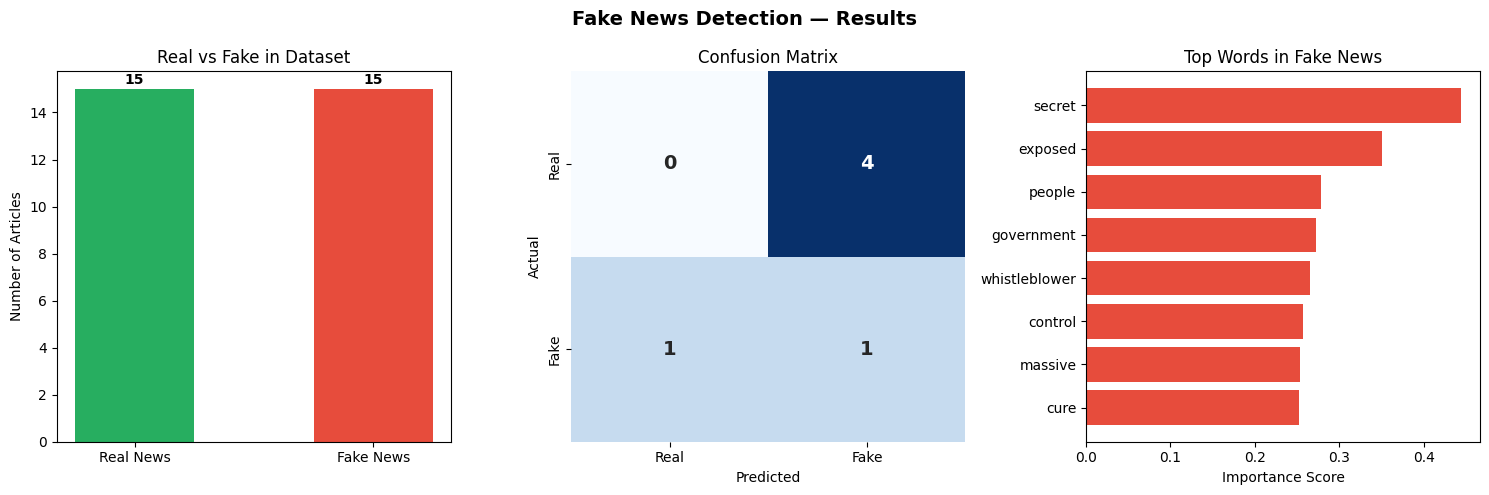

Charts saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fake News Detection — Results', fontsize=14, fontweight='bold')

# --- Chart 1: How many real vs fake in dataset ---
axes[0].bar(['Real News', 'Fake News'],
            [(df['label']==0).sum(), (df['label']==1).sum()],
            color=['#27ae60', '#e74c3c'], width=0.5)
axes[0].set_title('Real vs Fake in Dataset')
axes[0].set_ylabel('Number of Articles')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# --- Chart 2: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            ax=axes[1], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- Chart 3: Top words that indicate fake news ---
feature_names  = tfidf.get_feature_names_out()
top_fake_index = np.argsort(model.coef_[0])[-8:][::-1]
top_fake_words = [feature_names[i] for i in top_fake_index]
top_fake_vals  = [model.coef_[0][i] for i in top_fake_index]

axes[2].barh(top_fake_words[::-1], top_fake_vals[::-1], color='#e74c3c')
axes[2].set_title('Top Words in Fake News')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('fake_news_charts.png', dpi=120, bbox_inches='tight')
plt.show()
print('Charts saved!')